### Create a Graph where you pass a single list of integer along with a name and an operation. If the operation is a '+', add the elements and if it is a '*', multuply the elements, all within the same node

Input: {"name": "Sagar", "values" : [1,2,3,4], "operation" : "*"}

Output: "Hi Sagar, your answer is: 24"


In [16]:

from math import prod
from typing import Dict, TypedDict, List
from langgraph.graph import StateGraph

In [18]:
class AgentState(TypedDict):
  name : str
  values : List[int]
  operation : str
  result: str

def compute_values(state: AgentState) -> AgentState:
  res = (sum(state["values"]) if state["operation"] == "+" else prod(state["values"]))
  state["result"] = f"Hi {state['name']}, your answer is {res}"

  return state

graph = StateGraph(AgentState)

graph.add_node("Operator", compute_values) # Add node by passing it's name and the function it is going to perform
graph.set_entry_point("Operator") # set the starting node
graph.set_finish_point("Operator") # Set the ending node

app = graph.compile() #Compiling the graph

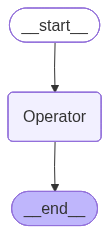

In [19]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [20]:
initialState = {"name":"Bob", "values":[1,2,3,4], "operation": "*"}
res = app.invoke(initialState)
print(res)

{'name': 'Bob', 'values': [1, 2, 3, 4], 'operation': '*', 'result': 'Hi Bob, your answer is 24'}
